# Flow-Matching + PPO Maze Solver (Chain-of-Sketch)

This notebook builds a small end-to-end pipeline for maze solving:
1. Generate random mazes and shortest-path traces.
2. Train a flow-matching sketcher to draw the path step by step.
3. Train a PPO agent that sees the maze + the sketch and navigates to the goal.

The default settings are intentionally small for quick MPS sanity checks.


In [1]:
%cd /Users/masha/Documents/visual-reasoning

/Users/masha/Documents/visual-reasoning


In [2]:
import math
import random
from collections import deque
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import gymnasium as gym

from stable_baselines3 import PPO


In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = get_device()
print("Device:", DEVICE)

# Fast sanity-check config (small)
RUN_FAST = False
IMG_SIZE = 64
MAZE_CELLS = 9  # number of maze cells per side (grid is 2*MAZE_CELLS+1)

TRAIN_SAMPLES = 500
TEST_SAMPLES = 100
BATCH_SIZE = 32
EPOCHS = 100
LR = 2e-4

PPO_STEPS = 100_000
EVAL_EPISODES = 30 if not RUN_FAST else 8
MAX_EP_STEPS = 180
EXPLORATION_EPS = 0.30
EXPLORATION_EPS_MIN = 0.05
EXPLORATION_DECAY = 0.9995
BC_EPISODES = 200
BC_EPOCHS = 5
BC_BATCH = 64
BC_LR = 1e-4

# Trace supervision mode
TRACE_MODE = "segment_path"  # "segment_path", "human_like", or "shortest_path"
HUMAN_TRACE_STYLE = "current_path"  # "current_path" or "visited"
GOAL_BIAS = 0.7
MAX_TRACE_STEPS = 800
SKETCH_THRESH = 0.6
FILTER_DISCONNECTED_SKETCH = True
SKETCH_FOLLOW_REWARD = 0.5
SKETCH_OFF_PENALTY = 0.1
SKETCH_DIST_SCALE = 0.0
RED_DIR_SCALE = 0.0  # disabled
TRACE_GOAL_SCALE = 0.0  # disabled
OFF_TRACE_PENALTY = 0.0
BACKTRACK_PENALTY = 0.0
GOAL_REWARD = 20.0
DIST_REWARD_SCALE = 0.0
NEW_CELL_BONUS = 0.0
REVISIT_PENALTY = 0.0







Device: mps


Maze generation, shortest path, and rasterization helpers.

In [4]:
def generate_maze(cells_w: int, cells_h: int, rng: random.Random) -> np.ndarray:
    """Generate a perfect maze with DFS backtracking. Returns grid with 1=wall, 0=free."""
    grid = np.ones((cells_h * 2 + 1, cells_w * 2 + 1), dtype=np.uint8)
    visited = np.zeros((cells_h, cells_w), dtype=bool)

    stack = [(0, 0)]
    visited[0, 0] = True
    grid[1, 1] = 0

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < cells_w and 0 <= ny < cells_h and not visited[ny, nx]:
                neighbors.append((nx, ny, dx, dy))
        if neighbors:
            nx, ny, dx, dy = rng.choice(neighbors)
            # carve wall between
            grid[y * 2 + 1 + dy, x * 2 + 1 + dx] = 0
            grid[ny * 2 + 1, nx * 2 + 1] = 0
            visited[ny, nx] = True
            stack.append((nx, ny))
        else:
            stack.pop()

    return grid


def bfs_shortest_path(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
    """Shortest path on grid (4-neighborhood). Returns list of (y, x)."""
    h, w = grid.shape
    q = deque([start])
    prev = {start: None}

    while q:
        y, x = q.popleft()
        if (y, x) == goal:
            break
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and grid[ny, nx] == 0:
                if (ny, nx) not in prev:
                    prev[(ny, nx)] = (y, x)
                    q.append((ny, nx))

    if goal not in prev:
        return []

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path


def path_to_trace(shape: Tuple[int, int], path: List[Tuple[int, int]], k: int) -> np.ndarray:
    trace = np.zeros(shape, dtype=np.float32)
    k = max(0, min(k, len(path) - 1))
    for y, x in path[: k + 1]:
        trace[y, x] = 1.0
    return trace

def nodes_to_trace(shape: Tuple[int, int], nodes: List[Tuple[int, int]]) -> np.ndarray:
    trace = np.zeros(shape, dtype=np.float32)
    for y, x in nodes:
        trace[y, x] = 1.0
    return trace


def human_like_trace_frames(
    grid: np.ndarray,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    rng: random.Random,
    goal_bias: float = 0.7,
    max_steps: int = 800,
    style: str = "current_path",
) -> List[List[Tuple[int, int]]]:
    """Human-like DFS with goal bias. Returns a list of node-lists (frames).
    style="current_path" shows the active path (with backtracking).
    style="visited" accumulates all visited cells (no erasing).
    """
    stack = [start]
    visited = {start}
    frames: List[List[Tuple[int, int]]] = []
    if style == "visited":
        visited_order = [start]
        frames.append(list(visited_order))
    else:
        frames.append(list(stack))

    steps = 0
    while stack and steps < max_steps:
        cur = stack[-1]
        if cur == goal:
            break
        neighbors = []
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = cur[0] + dy, cur[1] + dx
            if 0 <= ny < grid.shape[0] and 0 <= nx < grid.shape[1] and grid[ny, nx] == 0:
                if (ny, nx) not in visited:
                    neighbors.append((ny, nx))
        if neighbors:
            if rng.random() < goal_bias:
                dists = [abs(ny - goal[0]) + abs(nx - goal[1]) for ny, nx in neighbors]
                min_d = min(dists)
                candidates = [n for n, d in zip(neighbors, dists) if d == min_d]
                nxt = rng.choice(candidates)
            else:
                nxt = rng.choice(neighbors)
            stack.append(nxt)
            visited.add(nxt)
            if style == "visited":
                visited_order.append(nxt)
                frames.append(list(visited_order))
            else:
                frames.append(list(stack))
        else:
            stack.pop()
            if style == "current_path" and stack:
                frames.append(list(stack))
        steps += 1

    return frames

def one_hot_point(shape: Tuple[int, int], pos: Tuple[int, int]) -> np.ndarray:
    m = np.zeros(shape, dtype=np.float32)
    m[pos[0], pos[1]] = 1.0
    return m


def resize_nn(t: torch.Tensor, size: int) -> torch.Tensor:
    """Nearest-neighbor resize to IMG_SIZE. Accepts (H,W), (C,H,W), or (B,C,H,W)."""
    if t.dim() == 2:
        t = t.unsqueeze(0).unsqueeze(0)
    elif t.dim() == 3:
        t = t.unsqueeze(0)
    out = F.interpolate(t, size=(size, size), mode="nearest")
    return out.squeeze(0)


def build_cond(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int], img_size: int) -> torch.Tensor:
    walls = grid.astype(np.float32)
    start_ch = one_hot_point(grid.shape, start)
    goal_ch = one_hot_point(grid.shape, goal)
    cond = np.stack([walls, start_ch, goal_ch], axis=0)
    cond_t = torch.tensor(cond).float()
    return resize_nn(cond_t, img_size)




Dataset: random mazes with step-by-step traces (chain-of-sketch supervision).

In [5]:
# Guard: make sure segment helpers exist (handles out-of-order execution)
if "path_to_trace" not in globals():
    def path_to_trace(shape, path, k):
        trace = np.zeros(shape, dtype=np.float32)
        k = max(0, min(k, len(path) - 1))
        for y, x in path[: k + 1]:
            trace[y, x] = 1.0
        return trace

if "nodes_to_trace" not in globals():
    def nodes_to_trace(shape, nodes):
        trace = np.zeros(shape, dtype=np.float32)
        for y, x in nodes:
            trace[y, x] = 1.0
        return trace

if "segment_frames_from_path" not in globals():
    def path_to_segments(path):
        if not path:
            return []
        if len(path) == 1:
            return [[path[0]]]
        segments = []
        curr = [path[0]]
        curr_dir = (path[1][0] - path[0][0], path[1][1] - path[0][1])
        for i in range(1, len(path)):
            step = (path[i][0] - path[i - 1][0], path[i][1] - path[i - 1][1])
            if step != curr_dir:
                segments.append(curr)
                curr = [path[i - 1], path[i]]
                curr_dir = step
            else:
                curr.append(path[i])
        segments.append(curr)
        return segments

    def segment_frames_from_path(path):
        segments = path_to_segments(path)
        frames = [[]]
        current = []
        for seg in segments:
            if current and seg and current[-1] == seg[0]:
                current.extend(seg[1:])
            else:
                current.extend(seg)
            frames.append(list(current))
        return frames


class MazeTraceDataset(Dataset):
    def __init__(
        self,
        n_samples: int,
        maze_cells: int,
        img_size: int,
        seed: int = 0,
        min_path: int = 8,
        trace_mode: str = TRACE_MODE,
    ):
        self.n = n_samples
        self.maze_cells = maze_cells
        self.img_size = img_size
        self.min_path = min_path
        self.trace_mode = trace_mode
        self.rng = random.Random(seed)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        # generate maze + trace
        grid = generate_maze(self.maze_cells, self.maze_cells, self.rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)

        if self.trace_mode == "human_like":
            frames = human_like_trace_frames(
                grid,
                start,
                goal,
                self.rng,
                goal_bias=GOAL_BIAS,
                max_steps=MAX_TRACE_STEPS,
                style=HUMAN_TRACE_STYLE,
            )
            if len(frames) < self.min_path:
                return self.__getitem__(idx + 1)
            k = self.rng.randint(0, len(frames) - 2)
            trace_t = nodes_to_trace(grid.shape, frames[k])
            trace_next = nodes_to_trace(grid.shape, frames[k + 1])
            
            t = k / max(1, len(frames) - 1)
        elif self.trace_mode == "segment_path":
            path = bfs_shortest_path(grid, start, goal)
            frames = segment_frames_from_path(path)
            if len(frames) < self.min_path:
                return self.__getitem__(idx + 1)
            k = self.rng.randint(0, len(frames) - 2)
            trace_t = nodes_to_trace(grid.shape, frames[k])
            trace_next = nodes_to_trace(grid.shape, frames[k + 1])
            
            t = k / max(1, len(frames) - 1)
        elif self.trace_mode == "shortest_path":
            path = bfs_shortest_path(grid, start, goal)
            if len(path) < self.min_path:
                return self.__getitem__(idx + 1)
            k = self.rng.randint(0, len(path) - 2)
            trace_t = path_to_trace(grid.shape, path, k)
            trace_next = path_to_trace(grid.shape, path, k + 1)
            
            t = k / max(1, len(path) - 1)
        else:
            raise ValueError(f"Unknown trace_mode: {self.trace_mode}")

        delta = trace_next - trace_t
        cond = build_cond(grid, start, goal, self.img_size)
        trace_t = resize_nn(torch.tensor(trace_t).float(), self.img_size)
        delta = resize_nn(torch.tensor(delta).float(), self.img_size)

        return cond, trace_t, torch.tensor([t], dtype=torch.float32), delta


train_loader = DataLoader(
    MazeTraceDataset(TRAIN_SAMPLES, MAZE_CELLS, IMG_SIZE, seed=0),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    MazeTraceDataset(TEST_SAMPLES, MAZE_CELLS, IMG_SIZE, seed=123),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Visualize a few dataset samples **before training** (maze + partial trace).


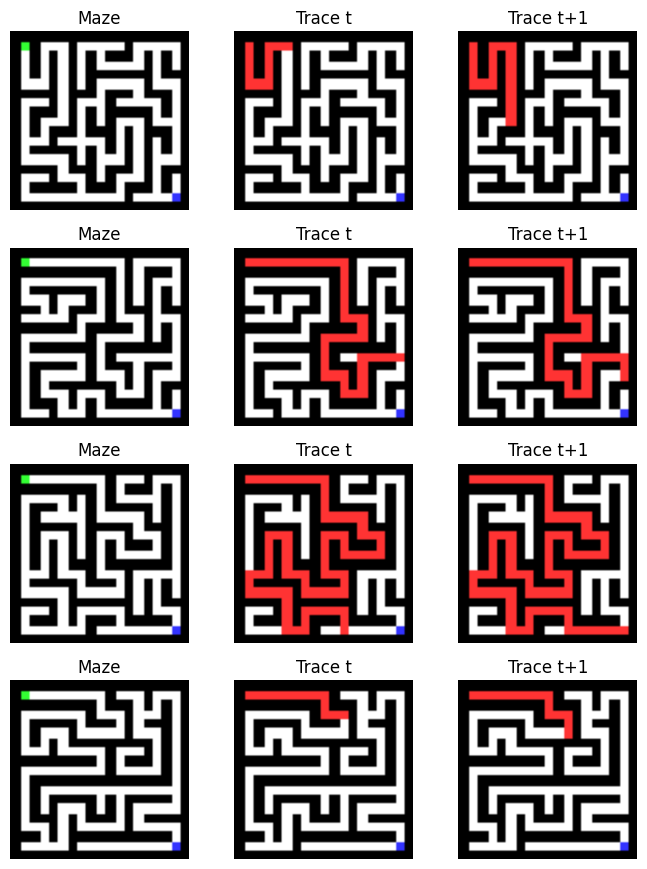

In [6]:
# --- Dataset visualization (pre-training) ---
batch = next(iter(train_loader))
cond, trace_t, t, delta = batch
trace_next = (trace_t + delta).clamp(0.0, 1.0)

n = min(4, cond.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(7, 2.2 * n))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

def compose_rgb_local(cond_i: np.ndarray, trace_i: np.ndarray | None = None) -> np.ndarray:
    walls = cond_i[0]
    start = cond_i[1]
    goal = cond_i[2]
    h, w = walls.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[walls > 0.5] = 0.0
    img[start > 0.5] = np.array([0.2, 1.0, 0.2])
    img[goal > 0.5] = np.array([0.2, 0.2, 1.0])
    if trace_i is not None:
        img[trace_i > 0.5] = np.array([1.0, 0.2, 0.2])
    return img

for i in range(n):
    cond_i = cond[i].numpy()
    t_i = trace_t[i, 0].numpy()
    tn_i = trace_next[i, 0].numpy()

    axes[i, 0].imshow(compose_rgb_local(cond_i))
    axes[i, 0].set_title("Maze")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(compose_rgb_local(cond_i, t_i))
    axes[i, 1].set_title("Trace t")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(compose_rgb_local(cond_i, tn_i))
    axes[i, 2].set_title("Trace t+1")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


Flow-matching sketcher (UNet with time + maze conditioning).

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class MazeSketcher(nn.Module):
    def __init__(self, cond_ch: int = 3, flow_dim: int = 32):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, flow_dim * 4), nn.GELU(), nn.Linear(flow_dim * 4, flow_dim * 4)
        )
        self.cond_encoder = nn.Sequential(
            nn.Conv2d(cond_ch, flow_dim, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(flow_dim, flow_dim * 2, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.cond_proj = nn.Linear(flow_dim * 2, flow_dim * 4)

        self.inc = DoubleConv(1 + cond_ch, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim * 2, flow_dim * 4))

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv1 = DoubleConv(flow_dim * 6, flow_dim * 2)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv2 = DoubleConv(flow_dim * 3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, trace_t: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if t.dim() == 1:
            t = t.unsqueeze(1)
        t_emb = self.time_mlp(t)
        c = self.cond_encoder(cond).squeeze(-1).squeeze(-1)
        c_emb = self.cond_proj(c)
        global_cond = (t_emb + c_emb).unsqueeze(-1).unsqueeze(-1)

        x = torch.cat([trace_t, cond], dim=1)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)


Train the sketcher (small sanity run).

In [ ]:
set_seed(0)

sketcher = MazeSketcher(cond_ch=3, flow_dim=32).to(DEVICE)
optimizer = torch.optim.AdamW(sketcher.parameters(), lr=LR)

train_losses = []
for epoch in range(EPOCHS):
    sketcher.train()
    epoch_loss = 0.0

    for cond, trace_t, t, delta in train_loader:
        cond = cond.to(DEVICE)
        trace_t = trace_t.to(DEVICE)
        t = t.to(DEVICE)
        delta = delta.to(DEVICE)

        pred = sketcher(trace_t, cond, t)
        loss = F.mse_loss(pred, delta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:02d} | loss {avg:.5f}")

plt.plot(train_losses)
plt.title("Sketcher train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

Visualize a chain-of-sketch rollout from the sketcher.

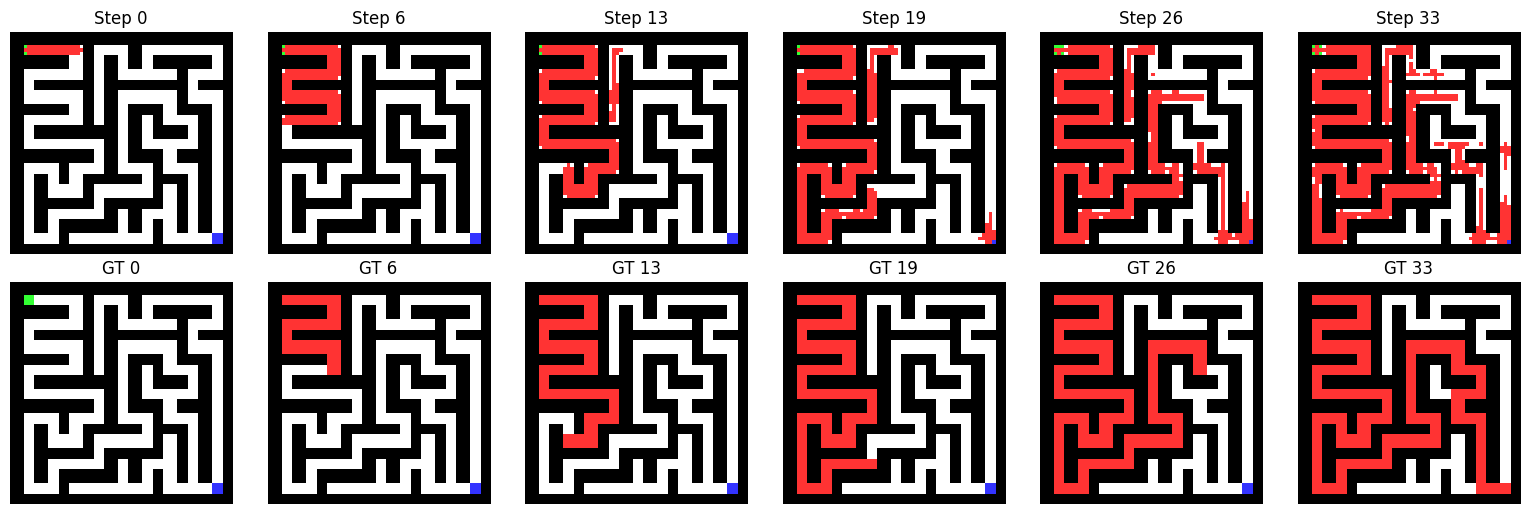

In [ ]:
@torch.no_grad()
def rollout_sketch(model: nn.Module, cond: torch.Tensor, steps: int, device: torch.device):
    model.eval()
    b, _, h, w = cond.shape
    trace = torch.zeros((b, 1, h, w), device=device)
    frames = []
    for i in range(steps):
        t = torch.tensor([[i / max(1, steps - 1)]], device=device)
        delta = model(trace, cond, t)
        trace = (trace + delta).clamp(0.0, 1.0)
        frames.append(trace.detach().cpu())
    return frames


def clean_trace(trace: torch.Tensor, walls: torch.Tensor, smooth: int = 3, thresh: float = 0.6) -> torch.Tensor:
    # Denoise + mask trace for clearer visualization.
    if trace.dim() == 2:
        t = trace.unsqueeze(0).unsqueeze(0)
    elif trace.dim() == 3:
        t = trace.unsqueeze(0)
    else:
        t = trace

    if smooth > 1:
        t = F.avg_pool2d(t, kernel_size=smooth, stride=1, padding=smooth // 2)

    if walls.dim() == 2:
        w = walls.unsqueeze(0).unsqueeze(0)
    elif walls.dim() == 3:
        w = walls.unsqueeze(0)
    else:
        w = walls

    free = (w <= 0.5).float()
    t = t * free
    t = (t > thresh).float()
    return t.squeeze()


def compose_rgb(cond: np.ndarray, trace: Optional[np.ndarray] = None, agent: Optional[np.ndarray] = None) -> np.ndarray:
    # cond: (3, H, W) => walls, start, goal
    walls = cond[0]
    start = cond[1]
    goal = cond[2]
    h, w = walls.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[walls > 0.5] = 0.0
    img[start > 0.5] = np.array([0.2, 1.0, 0.2])
    img[goal > 0.5] = np.array([0.2, 0.2, 1.0])
    if trace is not None:
        img[trace > 0.5] = np.array([1.0, 0.2, 0.2])
    if agent is not None:
        img[agent > 0.5] = np.array([1.0, 0.9, 0.1])
    return img


# sample maze + path
rng = random.Random(42)
grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
start = (1, 1)
goal = (grid.shape[0] - 2, grid.shape[1] - 2)
path = bfs_shortest_path(grid, start, goal)

cond_img = build_cond(grid, start, goal, IMG_SIZE)
cond_t = cond_img.unsqueeze(0).to(DEVICE)

if TRACE_MODE == "human_like":
    gt_frames = human_like_trace_frames(
        grid,
        start,
        goal,
        rng,
        goal_bias=GOAL_BIAS,
        max_steps=MAX_TRACE_STEPS,
        style=HUMAN_TRACE_STYLE,
    )
elif TRACE_MODE == "segment_path":
    gt_frames = segment_frames_from_path(path)
else:
    gt_frames = None

trace_steps = len(gt_frames) if gt_frames is not None else len(path)

frames = rollout_sketch(sketcher, cond_t, steps=trace_steps, device=DEVICE)

# visualization knobs
SHOW_GT = True
SHOW_DELTA = False  # if True, show only new pixels at each step
SMOOTH = 3
THRESH = 0.5

# show a few evenly spaced frames
idxs = np.linspace(0, len(frames) - 1, num=min(6, len(frames)), dtype=int)
rows = 2 if SHOW_GT else 1
fig, axes = plt.subplots(rows, len(idxs), figsize=(2.6 * len(idxs), 2.6 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

walls_t = cond_img[0]
prev = None
for col, i in enumerate(idxs):
    trace = frames[i][0, 0]
    if SHOW_DELTA and prev is not None:
        trace = (trace - prev).clamp(0.0, 1.0)
    prev = frames[i][0, 0]

    clean = clean_trace(trace, walls_t, smooth=SMOOTH, thresh=THRESH).numpy()
    img = compose_rgb(cond_img.numpy(), trace=clean)
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"Step {i}")
    axes[0, col].axis("off")

    if SHOW_GT:
        if TRACE_MODE == "human_like":
            gt_nodes = gt_frames[i]
            gt = nodes_to_trace(grid.shape, gt_nodes)
            gt_t = resize_nn(torch.tensor(gt).float(), IMG_SIZE)[0].numpy()
        elif TRACE_MODE == "segment_path":
            gt_nodes = gt_frames[i]
            gt = nodes_to_trace(grid.shape, gt_nodes)
            gt_t = resize_nn(torch.tensor(gt).float(), IMG_SIZE)[0].numpy()
        else:
            gt = path_to_trace(grid.shape, path, i)
            gt_t = resize_nn(torch.tensor(gt).float(), IMG_SIZE)[0].numpy()
        gt_img = compose_rgb(cond_img.numpy(), trace=gt_t)
        axes[1, col].imshow(gt_img)
        axes[1, col].set_title(f"GT {i}")
        axes[1, col].axis("off")

plt.tight_layout()
plt.show()

Gymnasium environment that feeds the FM sketch to PPO.

In [ ]:
class MazeEnvFM(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        sketcher: nn.Module,
        maze_cells: int = 9,
        img_size: int = 64,
        max_steps: int = 128,
        device: Optional[torch.device] = None,
        seed: int = 0,
    ):
        super().__init__()
        self.sketcher = sketcher
        self.maze_cells = maze_cells
        self.img_size = img_size
        self.max_steps = max_steps
        self.device = device or get_device()
        self.rng = random.Random(seed)

        # channels: walls, start, goal, agent, sketch
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(5, img_size, img_size), dtype=np.float32
        )
        self.action_space = gym.spaces.Discrete(4)  # up, down, left, right

        self.grid = None
        self.start = None
        self.goal = None
        self.pos = None
        self.step_idx = 0
        self.trace_frames = None
        self.trace_bin = None
        self.trace_frontiers = None
        self.sketch_k = 0
        self.trace_done = False
        self.cond_img = None
        self.prev_dist = None
        self.dist_map = None
        self.visited = None
        self.prev_sketch_dist = None
        self.prev_pos = None
        self.prev_prev_pos = None
        self.prev_trace_goal_dist = None


    def _filter_trace(self, trace: np.ndarray) -> np.ndarray:
        # trace: (1, H, W) float in [0,1]
        mask = (trace[0] > SKETCH_THRESH)
        walls = (self.cond_img[0] > 0.5)
        start_pos = np.argwhere(self.cond_img[1] > 0.5)
        if start_pos.size == 0:
            return trace
        sy, sx = start_pos[0]

        h, w = mask.shape
        out = np.zeros_like(mask, dtype=np.float32)
        visited = np.zeros_like(mask, dtype=bool)
        stack = [(int(sy), int(sx))]
        while stack:
            y, x = stack.pop()
            if visited[y, x]:
                continue
            visited[y, x] = True
            if walls[y, x] or not mask[y, x]:
                continue
            out[y, x] = 1.0
            for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                    stack.append((ny, nx))

        return out[None, ...]


    def _compute_dist_map(self) -> np.ndarray:
        # BFS distances from goal on free cells; walls get -1
        h, w = self.grid.shape
        dist = -np.ones((h, w), dtype=np.int32)
        gy, gx = self.goal
        if self.grid[gy, gx] == 1:
            return dist
        q = deque([(gy, gx)])
        dist[gy, gx] = 0
        while q:
            y, x = q.popleft()
            for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and self.grid[ny, nx] == 0 and dist[ny, nx] == -1:
                    dist[ny, nx] = dist[y, x] + 1
                    q.append((ny, nx))
        return dist


    def _sketch_distance(self, pos: Tuple[int, int], trace: np.ndarray) -> Optional[float]:
        ys, xs = np.where(trace > SKETCH_THRESH)
        if ys.size == 0:
            return None
        py, px = pos
        d = np.abs(ys - py) + np.abs(xs - px)
        return float(d.min())


    def _nearest_sketch_direction(self, pos: Tuple[int, int], trace: np.ndarray) -> Optional[Tuple[int, int]]:
        ys, xs = np.where(trace > SKETCH_THRESH)
        if ys.size == 0:
            return None
        py, px = pos
        d = np.abs(ys - py) + np.abs(xs - px)
        idx = int(d.argmin())
        ty, tx = int(ys[idx]), int(xs[idx])
        dy = np.sign(ty - py)
        dx = np.sign(tx - px)
        # prefer axis-aligned move
        if abs(ty - py) >= abs(tx - px):
            return (int(dy), 0)
        return (0, int(dx))


    def _trace_goal_dist(self, trace: np.ndarray) -> np.ndarray:
        # BFS on trace pixels + goal; returns dist map (int), -1 if unreachable
        h, w = trace.shape
        dist = -np.ones((h, w), dtype=np.int32)
        mask = (trace > SKETCH_THRESH)
        gy, gx = self.goal
        if 0 <= gy < h and 0 <= gx < w:
            mask[gy, gx] = True
        if not mask[gy, gx]:
            return dist
        q = deque([(gy, gx)])
        dist[gy, gx] = 0
        while q:
            y, x = q.popleft()
            for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and dist[ny, nx] == -1:
                    dist[ny, nx] = dist[y, x] + 1
                    q.append((ny, nx))
        return dist

    def _pos_channel(self) -> np.ndarray:
        pos_grid = one_hot_point(self.grid.shape, self.pos)
        pos_img = resize_nn(torch.tensor(pos_grid).float(), self.img_size).numpy()
        return pos_img

    def _obs(self) -> np.ndarray:
        idx = min(self.sketch_k, len(self.trace_frames) - 1)
        trace = self.trace_frames[idx]
        pos_ch = self._pos_channel()
        obs = np.concatenate([self.cond_img, pos_ch, trace], axis=0)
        return obs.astype(np.float32)

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = random.Random(seed)

        grid = generate_maze(self.maze_cells, self.maze_cells, self.rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)

        if TRACE_MODE == "human_like":
            ref_frames = human_like_trace_frames(
                grid,
                start,
                goal,
                self.rng,
                goal_bias=GOAL_BIAS,
                max_steps=MAX_TRACE_STEPS,
                style=HUMAN_TRACE_STYLE,
            )
            trace_steps = len(ref_frames)
        elif TRACE_MODE == "segment_path":
            path = bfs_shortest_path(grid, start, goal)
            ref_frames = segment_frames_from_path(path)
            trace_steps = len(ref_frames)
        else:
            path = bfs_shortest_path(grid, start, goal)
            trace_steps = len(path)

        self.grid = grid
        self.start = start
        self.goal = goal
        self.pos = start
        self.step_idx = 0
        self.dist_map = self._compute_dist_map()
        self.prev_dist = int(self.dist_map[start[0], start[1]]) if self.dist_map is not None else 0
        self.visited = {start}

        cond_img = build_cond(grid, start, goal, self.img_size)
        self.cond_img = cond_img.numpy()
        cond_t = cond_img.unsqueeze(0).to(self.device)

        with torch.no_grad():
            frames = rollout_sketch(self.sketcher, cond_t, steps=trace_steps, device=self.device)
        self.trace_frames = [f[0].numpy() for f in frames]  # (1, H, W) each
        if FILTER_DISCONNECTED_SKETCH:
            self.trace_frames = [self._filter_trace(f) for f in self.trace_frames]

        # Precompute binary traces + frontiers for gated sketch progression
        self.trace_bin = [(f[0] > SKETCH_THRESH) for f in self.trace_frames]
        self.trace_frontiers = []
        for i in range(len(self.trace_bin) - 1):
            self.trace_frontiers.append(self.trace_bin[i + 1] & ~self.trace_bin[i])
        self.sketch_k = 0
        self.trace_done = False

        trace0 = self.trace_frames[0][0] if self.trace_frames else None
        self.prev_sketch_dist = self._sketch_distance(self.pos, trace0) if trace0 is not None else None
        self.prev_pos = self.pos
        self.prev_prev_pos = None
        self.prev_trace_goal_dist = None

        return self._obs(), {"path_len": trace_steps}

    def step(self, action: int):
        y, x = self.pos
        dy, dx = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}[int(action)]
        ny, nx = y + dy, x + dx

        reward = -0.01
        if 0 <= ny < self.grid.shape[0] and 0 <= nx < self.grid.shape[1] and self.grid[ny, nx] == 0:
            self.pos = (ny, nx)
        else:
            reward -= 0.05  # bump into wall

        dist = int(self.dist_map[self.pos[0], self.pos[1]]) if self.dist_map is not None else 0
        if dist >= 0:
            reward += (self.prev_dist - dist) * DIST_REWARD_SCALE
            self.prev_dist = dist
        else:
            reward -= 0.05

        if self.visited is not None:
            if self.pos in self.visited:
                reward -= REVISIT_PENALTY
            else:
                reward += NEW_CELL_BONUS
                self.visited.add(self.pos)

        # sketch-follow shaping (optional)
        # sketch distance shaping (optional)
        # red direction reward (optional)
        if RED_DIR_SCALE > 0.0 and self.prev_pos is not None:
            trace = self.trace_frames[min(self.step_idx, len(self.trace_frames) - 1)][0]
            target_dir = self._nearest_sketch_direction(self.prev_pos, trace)
            move = (self.pos[0] - self.prev_pos[0], self.pos[1] - self.prev_pos[1])
            if target_dir is not None and move == target_dir:
                reward += RED_DIR_SCALE
        # trace-to-goal shaping (optional)
        if TRACE_GOAL_SCALE > 0.0:
            trace = self.trace_frames[min(self.step_idx, len(self.trace_frames) - 1)][0]
            dist_map = self._trace_goal_dist(trace)
            d = int(dist_map[self.pos[0], self.pos[1]]) if dist_map is not None else -1
            if d >= 0:
                if self.prev_trace_goal_dist is not None:
                    reward += (self.prev_trace_goal_dist - d) * TRACE_GOAL_SCALE
                self.prev_trace_goal_dist = d
            else:
                reward -= OFF_TRACE_PENALTY

        # backtrack penalty (immediate oscillation)
        if self.prev_prev_pos is not None and self.pos == self.prev_prev_pos:
            reward -= BACKTRACK_PENALTY

        self.prev_prev_pos = self.prev_pos
        self.prev_pos = self.pos

        if SKETCH_DIST_SCALE > 0.0:
            trace = self.trace_frames[min(self.step_idx, len(self.trace_frames) - 1)][0]
            dist_to_sketch = self._sketch_distance(self.pos, trace)
            if dist_to_sketch is not None and self.prev_sketch_dist is not None:
                reward += (self.prev_sketch_dist - dist_to_sketch) * SKETCH_DIST_SCALE
            self.prev_sketch_dist = dist_to_sketch

        if (SKETCH_FOLLOW_REWARD > 0.0 or SKETCH_OFF_PENALTY > 0.0) and (not self.trace_done):
            trace = self.trace_frames[min(self.step_idx, len(self.trace_frames) - 1)][0]
            pos_ch = self._pos_channel()[0]
            pos_idx = np.argwhere(pos_ch > 0.5)
            if pos_idx.size > 0:
                py, px = pos_idx[0]
                if trace[int(py), int(px)] > SKETCH_THRESH:
                    reward += SKETCH_FOLLOW_REWARD
                else:
                    reward -= SKETCH_OFF_PENALTY

        terminated = (self.pos == self.goal)
        if terminated:
            reward += GOAL_REWARD

        self.step_idx += 1
        truncated = self.step_idx >= self.max_steps

        info = {"pos": self.pos, "goal": self.goal}
        return self._obs(), float(reward), terminated, truncated, info


class EpsGreedyActionWrapper(gym.Wrapper):
    def __init__(self, env: gym.Env, eps: float = 0.3, eps_min: float = 0.05, eps_decay: float = 0.9995):
        super().__init__(env)
        self.eps = float(eps)
        self.eps_min = float(eps_min)
        self.eps_decay = float(eps_decay)

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

    def step(self, action):
        if np.random.rand() < self.eps:
            action = self.action_space.sample()
        obs, reward, terminated, truncated, info = self.env.step(action)
        if self.eps > self.eps_min:
            self.eps = max(self.eps_min, self.eps * self.eps_decay)
        info["exploration_eps"] = self.eps
        return obs, reward, terminated, truncated, info


Train PPO using the FM sketch as a visual hint.

In [ ]:
set_seed(0)

base_env = MazeEnvFM(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=0,
)

maze_env = EpsGreedyActionWrapper(
    base_env,
    eps=EXPLORATION_EPS,
    eps_min=EXPLORATION_EPS_MIN,
    eps_decay=EXPLORATION_DECAY,
)

model = PPO(
    "CnnPolicy",
    maze_env,
    verbose=1,
    device="mps" if DEVICE.type == "mps" else DEVICE,
    learning_rate=2e-4,
    ent_coef=0.02,
    policy_kwargs={"normalize_images": False},
)


from stable_baselines3.common.logger import configure
log_dir = "logs/ppo_maze_fm"
logger = configure(log_dir, ["stdout", "csv"])
model.set_logger(logger)


# --- Behavior cloning warm-start (oracle shortest-path actions) ---
from torch.utils.data import TensorDataset, DataLoader

def path_to_actions(path):
    actions = []
    for (y0, x0), (y1, x1) in zip(path[:-1], path[1:]):
        if y1 == y0 - 1:
            actions.append(0)
        elif y1 == y0 + 1:
            actions.append(1)
        elif x1 == x0 - 1:
            actions.append(2)
        elif x1 == x0 + 1:
            actions.append(3)
    return actions

def collect_bc_dataset(env: MazeEnvFM, n_episodes: int):
    obs_list = []
    act_list = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        path = bfs_shortest_path(env.grid, env.start, env.goal)
        actions = path_to_actions(path)
        for a in actions:
            obs_list.append(obs)
            act_list.append(a)
            obs, _, terminated, truncated, _ = env.step(int(a))
            if terminated or truncated:
                break
    obs_arr = np.stack(obs_list).astype(np.float32)
    act_arr = np.array(act_list, dtype=np.int64)
    return obs_arr, act_arr

bc_obs, bc_act = collect_bc_dataset(base_env, BC_EPISODES)
print(f"BC dataset: {bc_obs.shape[0]} steps")

tensor_ds = TensorDataset(torch.from_numpy(bc_obs), torch.from_numpy(bc_act))
loader = DataLoader(tensor_ds, batch_size=BC_BATCH, shuffle=True)

policy = model.policy
policy.train()
optim = torch.optim.Adam(policy.parameters(), lr=BC_LR)

for epoch in range(BC_EPOCHS):
    losses = []
    for obs_b, act_b in loader:
        obs_b = obs_b.to(policy.device)
        act_b = act_b.to(policy.device)
        dist = policy.get_distribution(obs_b)
        log_prob = dist.log_prob(act_b)
        loss = -log_prob.mean()
        optim.zero_grad()
        loss.backward()
        optim.step()
        losses.append(loss.item())
    print(f"BC epoch {epoch+1}: {np.mean(losses):.4f}")

model.learn(total_timesteps=PPO_STEPS)


Using mps device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to logs/ppo_maze_fm
BC dataset: 15636 steps
BC epoch 1: 1.3047
BC epoch 2: 1.2989
BC epoch 3: 1.2895
BC epoch 4: 1.1891
BC epoch 5: 0.9767
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 180      |
|    ep_rew_mean     | -9.31    |
| time/              |          |
|    fps             | 299      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 180         |
|    ep_rew_mean          | -8.26       |
| time/                   |             |
|    fps                  | 206         |
|    iterations           | 2           |
|    time_elapsed         | 19          |
|    total_timesteps      | 4096        |
| train/                  |             |

Evaluate success rate on fresh mazes.

In [ ]:
eval_env = MazeEnvFM(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=123,
)

success = 0
rewards = []
for _ in range(EVAL_EPISODES):
    obs, _ = eval_env.reset()
    terminated = False
    truncated = False
    ep_reward = 0.0

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env.step(int(action))
        ep_reward += reward

    rewards.append(ep_reward)
    if terminated:
        success += 1

print(f"Mean episode reward: {np.mean(rewards):.2f}")
print(f"Success rate: {success / EVAL_EPISODES:.2%}")


Mean episode reward: -7.43
Success rate: 0.00%


Plot PPO losses


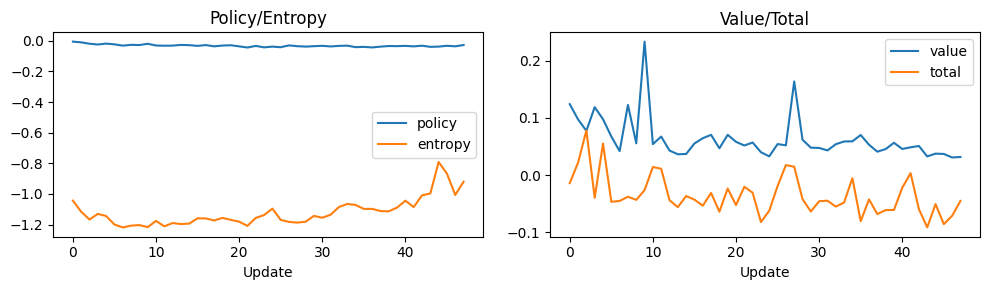

In [ ]:
import csv
import os

log_path = os.path.join(log_dir, "progress.csv")
if not os.path.exists(log_path):
    print(f"No progress.csv found at {log_path}. Did training run?")
else:
    with open(log_path, "r", newline="") as f:
        rows = list(csv.DictReader(f))

    def get_series(key: str):
        vals = []
        for r in rows:
            v = r.get(key, "")
            if v != "" and v is not None:
                vals.append(float(v))
        return vals

    policy_loss = get_series("train/policy_gradient_loss")
    value_loss = get_series("train/value_loss")
    entropy_loss = get_series("train/entropy_loss")
    total_loss = get_series("train/loss")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    if policy_loss:
        axes[0].plot(policy_loss, label="policy")
    if entropy_loss:
        axes[0].plot(entropy_loss, label="entropy")
    axes[0].set_title("Policy/Entropy")
    axes[0].set_xlabel("Update")
    axes[0].legend()

    if value_loss:
        axes[1].plot(value_loss, label="value")
    if total_loss:
        axes[1].plot(total_loss, label="total")
    axes[1].set_title("Value/Total")
    axes[1].set_xlabel("Update")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Visualize a rollout (maze + sketch + agent).

gifs/maze/maze_ppo_fm_sample.gif


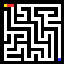

In [ ]:
import imageio.v2 as imageio
import os
from IPython.display import Image, display


def render_env_frame(env: MazeEnvFM) -> np.ndarray:
    cond = env.cond_img
    trace = env.trace_frames[min(env.step_idx, len(env.trace_frames) - 1)][0]
    pos = env._pos_channel()[0]
    img = compose_rgb(cond, trace=trace, agent=pos)
    return (img * 255).astype(np.uint8)


def rollout_and_save_gif(
    env: MazeEnvFM,
    model: PPO,
    out_path: str = "gifs/maze/maze_ppo_fm.gif",
    max_steps: int = 120,
    fps: int = 6,
):
    obs, _ = env.reset()
    frames = []
    for _ in range(max_steps):
        frames.append(render_env_frame(env))

        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(int(action))
        if terminated or truncated:
            frames.append(render_env_frame(env))
            break

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imageio.mimsave(out_path, frames, fps=fps)
    return out_path


gif_env = MazeEnvFM(
    sketcher=sketcher,
    maze_cells=MAZE_CELLS,
    img_size=IMG_SIZE,
    max_steps=MAX_EP_STEPS,
    device=DEVICE,
    seed=998,
)

path = rollout_and_save_gif(gif_env, model, out_path="gifs/maze/maze_ppo_fm_sample.gif")

print(path)
display(Image(filename=path))